In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, roc_auc_score, f1_score, log_loss
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализаций
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

X_train = pd.read_csv('processed/splits/X_train_all.csv')
X_val   = pd.read_csv('processed/splits/X_val_all.csv')
X_test  = pd.read_csv('processed/splits/X_test_all.csv')

y_train = pd.read_csv('processed/splits/y_train_all.csv').squeeze()
y_val   = pd.read_csv('processed/splits/y_val_all.csv').squeeze()
y_test  = pd.read_csv('processed/splits/y_test_all.csv').squeeze()

print(f"Форма данных: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}")

Форма данных: Train=(3180741, 55), Val=(681587, 55), Test=(681588, 55)


LightGBM не принимает названия колонок со спецсимволами ([, ], {, }, ", , и т.д.). Нужно очистить имена признаков сразу после загрузки данных.

In [8]:
import re

def clean_col_names(df):
    df = df.copy()
    # Шаг 1: базовая очистка
    cleaned = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    
    # Шаг 2: разрешение дубликатов добавлением суффикса _1, _2 и т.д.
    seen = {}
    final_names = []
    for name in cleaned:
        if name in seen:
            seen[name] += 1
            final_names.append(f"{name}_{seen[name]}")
        else:
            seen[name] = 0
            final_names.append(name)
    
    df.columns = final_names
    return df

X_train = clean_col_names(X_train)
X_val   = clean_col_names(X_val)
X_test  = clean_col_names(X_test)

print("Примеры имён признаков после очистки:", list(X_train.columns[:5]))

Примеры имён признаков после очистки: ['TCP_Destination_Port', 'UDP_Checksum', 'IP_Fragment_Offset_0_0', 'IP_Fragment_Offset_0', 'UDP_Source_Port']


In [9]:
dups = X_train.columns[X_train.columns.duplicated()]
if len(dups) > 0:
    print(f" Осталось дубликатов: {list(dups)}")
else:
    print("Дубликаты имён признаков устранены")

Дубликаты имён признаков устранены


In [10]:
# LightGBM требует числовые метки [0..K-1], поэтому используем LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded   = le.transform(y_val)
y_test_encoded  = le.transform(y_test)

num_classes = len(le.classes_)
classes_int = np.arange(num_classes)

print(f"Уникальных классов: {num_classes}")
print(f"Названия классов: {le.classes_.tolist()}")

# Вычисляем веса для балансировки дисбаланса
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes_int,
    y=y_train_encoded
)
weight_dict = dict(zip(classes_int, class_weights_arr))

# Массивы весов для передачи в sample_weight
w_train = np.array([weight_dict[c] for c in y_train_encoded], dtype=np.float32)
w_val   = np.array([weight_dict[c] for c in y_val_encoded],   dtype=np.float32)

# Таблица весов по классам
class_counts = y_train.value_counts().sort_index()
print(f"\n{'Класс':<25} {'Кол-во':>10} {'Вес':>10} {'Относит.':>14}")
print("-" * 62)
for i, cls in enumerate(le.classes_):
    count  = class_counts.get(cls, 0)
    weight = class_weights_arr[i]
    rel    = weight / class_weights_arr.min()
    print(f"{cls:<25} {count:>10,} {weight:>10.4f} {rel:>14.2f}x")

print(f"\n   • Минимальный вес: {class_weights_arr.min():.4f} (класс-большинство)")
print(f"   • Максимальный вес: {class_weights_arr.max():.4f} (класс-меньшинство)")
print(f"   • Разница в {class_weights_arr.max()/class_weights_arr.min():.1f} раз")

Уникальных классов: 14
Названия классов: ['ARP-spoof', 'Benign', 'DDoS', 'DoS', 'FTP-Attack', 'FTP-Brute-Force', 'Fuzzing', 'ICMP-Flood', 'Port-Scanning', 'RCE', 'SQL-Injection', 'SSH-Brute-Force', 'SYN-Flood', 'XSS']

Класс                         Кол-во        Вес       Относит.
--------------------------------------------------------------
ARP-spoof                     67,827     3.3496          13.00x
Benign                       881,629     0.2577           1.00x
DDoS                         591,279     0.3842           1.49x
DoS                          258,502     0.8789           3.41x
FTP-Attack                   145,462     1.5619           6.06x
FTP-Brute-Force               85,341     2.6622          10.33x
Fuzzing                       82,291     2.7609          10.71x
ICMP-Flood                   168,057     1.3519           5.25x
Port-Scanning                113,623     1.9996           7.76x
RCE                          195,211     1.1638           4.52x
SQL-Injection  

## Подбор гиперпараметров с Optuna
В данной работе применён подход AutoML с использованием библиотеки **Optuna**
для подбора гиперпараметров модели **LightGBM**.
Для ускорения поиска используется стратифицированная подвыборка обучающих данных (8%),
которая сохраняет представительность распределения классов.
Оптимальные параметры ищутся путём минимизации метрики **multi_logloss**
с применением алгоритма **TPE** и MedianPruner для раннего завершения слабых trial-ов.
Финальная модель дообучается на полном train с учётом весов классов.
**Ключевые отличия LightGBM от XGBoost:**
- Leaf-wise рост деревьев (быстрее сходится, точнее на несбалансированных данных)
- `num_leaves` вместо `max_depth` — главный параметр сложности
- Значительно быстрее на больших данных (GOSS, EFB)
- `class_weight` передаётся через `sample_weight`

In [11]:
import optuna
from sklearn.model_selection import StratifiedShuffleSplit

RANDOM_STATE      = 42
N_TRIALS          = 30       # до 50-80 для лучшего результата
TRAIN_SAMPLE_FRAC = 0.08     # 8% train для быстрого поиска
EARLY_STOPPING    = 50
MODEL_DIR         = "processed/models/lgbm"
os.makedirs(MODEL_DIR, exist_ok=True)

# Стратифицированная подвыборка для Optuna
sss = StratifiedShuffleSplit(
    n_splits=1, train_size=TRAIN_SAMPLE_FRAC, random_state=RANDOM_STATE
)
idx_small, _ = next(sss.split(X_train, y_train_encoded))

X_train_s = X_train.iloc[idx_small]
y_train_s = y_train_encoded[idx_small]
w_train_s = w_train[idx_small]

print(f"Train full: {X_train.shape}, sampled: {X_train_s.shape}, Val: {X_val.shape}")

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective":         "multiclass",
        "num_class":         num_classes,
        "metric":            "multi_logloss",
        "verbosity":         -1,
        "boosting_type":     "gbdt",
        "random_state":      RANDOM_STATE,
        "n_jobs":            -1,
        # --- подбираемые параметры ---
        "n_estimators":      trial.suggest_int("n_estimators",    200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "num_leaves":        trial.suggest_int("num_leaves",      31, 255),
        "max_depth":         trial.suggest_int("max_depth",       -1, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample",     0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha",     0.0, 2.0),
        "reg_lambda":        trial.suggest_float("reg_lambda",    1.0, 20.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_train_s, y_train_s,
        sample_weight=w_train_s,
        eval_set=[(X_val, y_val_encoded)],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    proba = model.predict_proba(X_val)
    mll   = log_loss(y_val_encoded, proba, labels=np.arange(num_classes))
    return float(mll)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="minimize",
    study_name="lgbm_mlogloss",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest mlogloss: {study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

Train full: (3180741, 55), sampled: (254459, 55), Val: (681587, 55)


Best trial: 7. Best value: 0.0456427:  63%|██████▎   | 19/30 [09:09<05:18, 28.92s/it]

[W 2026-05-24 19:37:53,222] Trial 19 failed with parameters: {'n_estimators': 494, 'learning_rate': 0.020134217534599104, 'num_leaves': 64, 'max_depth': 8, 'min_child_samples': 6, 'subsample': 0.799851648280213, 'colsample_bytree': 0.9229285736055094, 'reg_alpha': 1.9626261735165866, 'reg_lambda': 1.5068629229154282, 'min_split_gain': 0.8690193908638018} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\аля\AppData\Local\Temp\ipykernel_2272\857543505.py", line 46, in objective
    model.fit(
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\lightgbm\sklearn.py", line 1560, in fit
    super().fit(
  File "d:\anaconda\anaconda3\envs\notebook\Lib\site-packages\lightgbm\sklearn.py", line 1049, in fit
    self._Booster = train(
                  

KeyboardInterrupt: 

In [12]:
import optuna
from sklearn.model_selection import StratifiedShuffleSplit

RANDOM_STATE      = 42
N_TRIALS          = 20          # Уменьшено с 30 → 20 (быстрее)
TRAIN_SAMPLE_FRAC = 0.03        #  Уменьшено с 0.08 → 0.03 (3% train)
EARLY_STOPPING    = 30          # Уменьшено с 50 → 30
MAX_CPU_THREADS   = 2           #  Ограничение потоков для снижения нагрузки на ЦП
MODEL_DIR         = "processed/models/lgbm"
os.makedirs(MODEL_DIR, exist_ok=True)

# Стратифицированная подвыборка для Optuna
sss = StratifiedShuffleSplit(
    n_splits=1, train_size=TRAIN_SAMPLE_FRAC, random_state=RANDOM_STATE
)
idx_small, _ = next(sss.split(X_train, y_train_encoded))

X_train_s = X_train.iloc[idx_small]
y_train_s = y_train_encoded[idx_small]
w_train_s = w_train[idx_small]

print(f"Train full: {X_train.shape}, sampled: {X_train_s.shape}, Val: {X_val.shape}")

def objective(trial: optuna.Trial) -> float:
    params = {
        "objective":         "multiclass",
        "num_class":         num_classes,
        "metric":            "multi_logloss",
        "verbosity":         -1,
        "boosting_type":     "gbdt",
        "random_state":      RANDOM_STATE,
        "n_jobs":            MAX_CPU_THREADS,  # Ограничение потоков
        "force_col_wise":    True,              #  Ускорение на больших данных
        # --- суженные диапазоны для быстрого поиска ---
        "n_estimators":      trial.suggest_int("n_estimators",    100, 300),   # Было 200-800
        "learning_rate":     trial.suggest_float("learning_rate", 0.05, 0.15, log=True),  # Уже диапазон
        "num_leaves":        trial.suggest_int("num_leaves",      31, 127),    # Было 31-255
        "max_depth":         trial.suggest_int("max_depth",       6, 10),       # Только положительные
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 50),   # Было 5-100
        "subsample":         trial.suggest_float("subsample",     0.7, 0.9),   # Уже диапазон
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.7, 0.9),# Уже диапазон
        "reg_alpha":         trial.suggest_float("reg_alpha",     0.0, 1.0),   # Было 0.0-2.0
        "reg_lambda":        trial.suggest_float("reg_lambda",    1.0, 10.0, log=True), # Было 1.0-20.0
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 0.5),  # Было 0.0-1.0
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_train_s, y_train_s,
        sample_weight=w_train_s,
        eval_set=[(X_val, y_val_encoded)],
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING, verbose=False),
            lgb.log_evaluation(period=-1)
        ]
    )

    proba = model.predict_proba(X_val)
    mll   = log_loss(y_val_encoded, proba, labels=np.arange(num_classes))
    return float(mll)


optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="minimize",
    study_name="lgbm_mlogloss",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=10)  # Агрессивнее отсев
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest mlogloss: {study.best_value:.6f}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

Train full: (3180741, 55), sampled: (95422, 55), Val: (681587, 55)


Best trial: 11. Best value: 0.049246: 100%|██████████| 20/20 [20:15<00:00, 60.80s/it]


Best mlogloss: 0.049246
Best params:
   n_estimators: 261
   learning_rate: 0.07821062215903053
   num_leaves: 82
   max_depth: 10
   min_child_samples: 41
   subsample: 0.8919423569452742
   colsample_bytree: 0.8291875086333805
   reg_alpha: 0.00526826260709401
   reg_lambda: 1.877119579873326
   min_split_gain: 0.15136263808383352


In [13]:
best_params = study.best_params.copy()

final_model = LGBMClassifier(
    **best_params,
    objective="multiclass",
    num_class=num_classes,
    metric="multi_logloss",
    verbosity=-1,
    boosting_type="gbdt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

final_model.fit(
    X_train, y_train_encoded,
    sample_weight=w_train,
    eval_set=[(X_val, y_val_encoded)],
    callbacks=[
        lgb.early_stopping(200, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Лучшая итерация: {final_model.best_iteration_}")
print(f"Число деревьев:  {final_model.n_estimators_}")

[100]	valid_0's multi_logloss: 0.0420365
[200]	valid_0's multi_logloss: 0.0409267
Лучшая итерация: 260
Число деревьев:  260


In [14]:
y_val_pred   = final_model.predict(X_val)
y_val_proba  = final_model.predict_proba(X_val)
y_train_pred = final_model.predict(X_train)
y_test_pred  = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)

train_acc = accuracy_score(y_train_encoded, y_train_pred)
val_acc   = accuracy_score(y_val_encoded,   y_val_pred)
test_acc  = accuracy_score(y_test_encoded,  y_test_pred)

macro_f1    = f1_score(y_val_encoded, y_val_pred, average='macro')
weighted_f1 = f1_score(y_val_encoded, y_val_pred, average='weighted')

roc_macro = roc_auc_score(y_val_encoded, y_val_proba, average='macro', multi_class='ovr')
roc_micro = roc_auc_score(y_val_encoded, y_val_proba, average='micro', multi_class='ovr')

print("Accuracy:")
print(f"   Train : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   Val   : {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"   Test  : {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\nF1-Score (Val):")
print(f"   Macro F1:    {macro_f1:.4f}")
print(f"   Weighted F1: {weighted_f1:.4f}")

print("\nROC-AUC (Val):")
print(f"   Macro AUC: {roc_macro:.4f}")
print(f"   Micro AUC: {roc_micro:.4f}")

diff = abs(train_acc - val_acc)
print(f"\nРазница Train vs Val: {diff:.4f} ({diff*100:.2f}%)")
if diff < 0.02:
    print("   Переобучения не обнаружено (разница < 2%)")
elif diff < 0.05:
    print("   Умеренная разница — возможно небольшое переобучение")
else:
    print("   Значительная разница (>5%) — возможен overfitting")

Accuracy:
   Train : 0.9811 (98.11%)
   Val   : 0.9801 (98.01%)
   Test  : 0.9803 (98.03%)

F1-Score (Val):
   Macro F1:    0.9755
   Weighted F1: 0.9803

ROC-AUC (Val):
   Macro AUC: 0.9997
   Micro AUC: 0.9999

Разница Train vs Val: 0.0011 (0.11%)
   Переобучения не обнаружено (разница < 2%)


Топ-5 лучших по AUC:
        class      auc
    SYN-Flood 1.000000
         DDoS 1.000000
   ICMP-Flood 1.000000
Port-Scanning 0.999999
   FTP-Attack 0.999997

Топ-5 худших по AUC:
        class      auc
       Benign 0.999867
SQL-Injection 0.999854
          RCE 0.999699
          DoS 0.998870
          XSS 0.998102

Макро-AUC: 0.9997  |  Микро-AUC: 0.9999


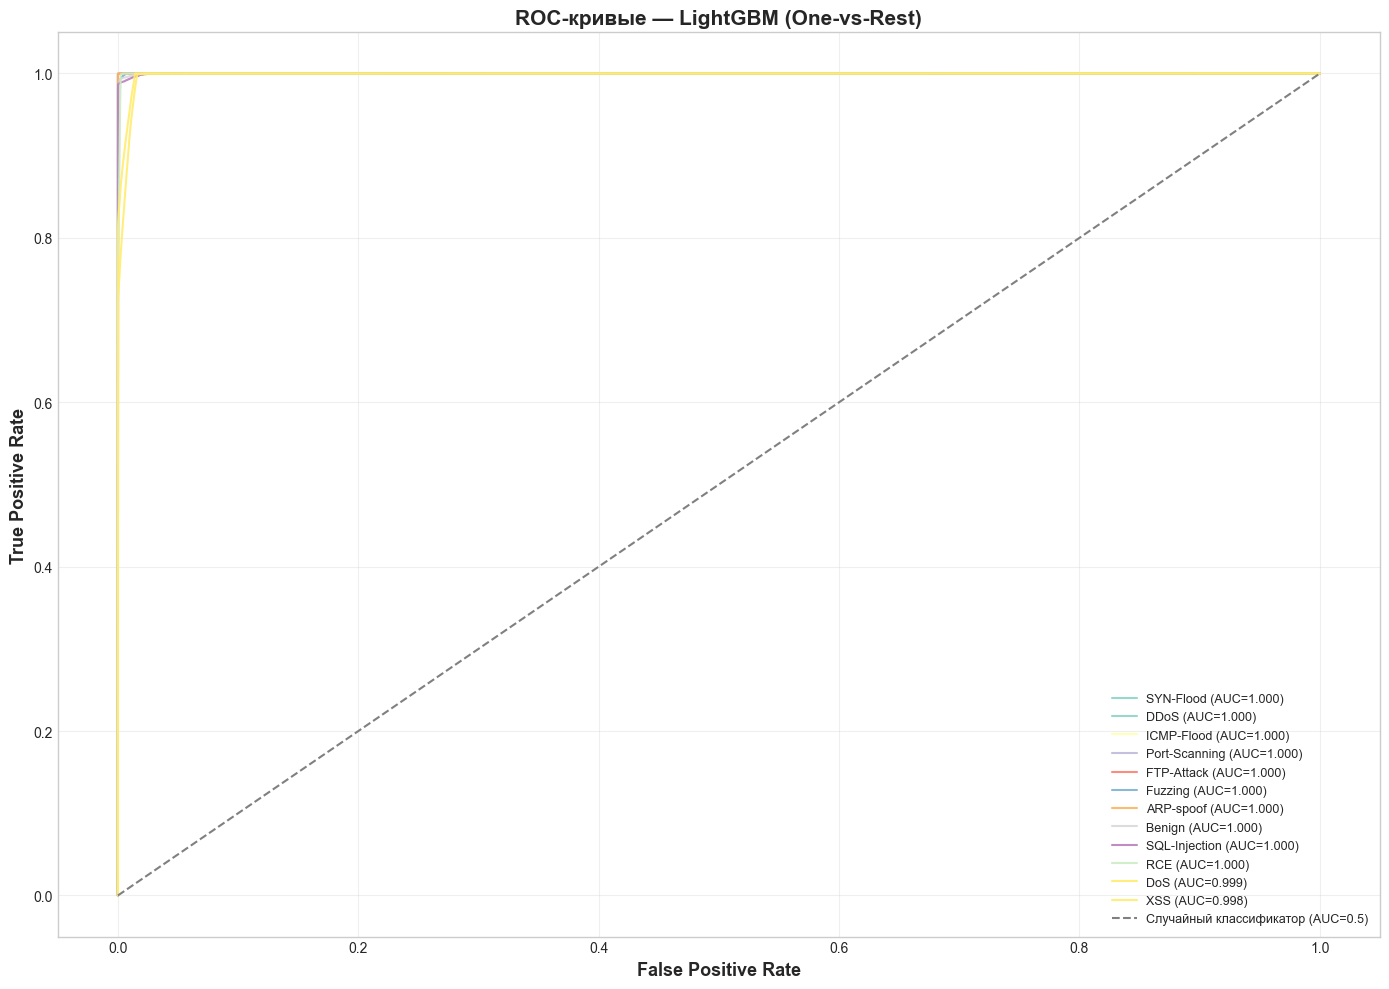

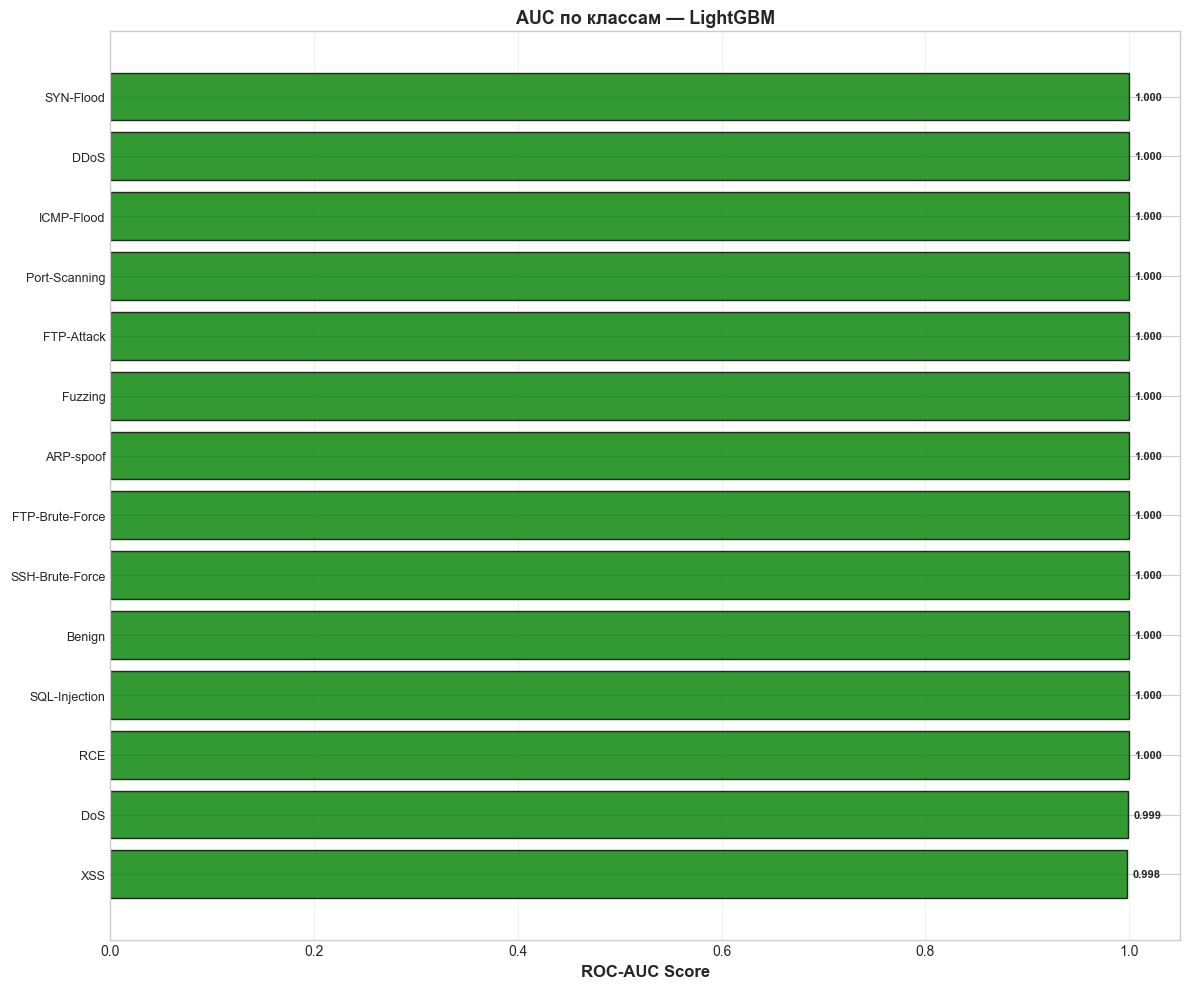


Статистика (14 классов):
   Отличные (AUC >= 0.9):        14
   Хорошие (0.7 <= AUC < 0.9):   0
   Слабые  (AUC < 0.7):           0


In [15]:
class_aucs = []
for i, cls_name in enumerate(le.classes_):
    y_bin = (y_val_encoded == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_val_proba[:, i])
    class_aucs.append({'class': cls_name, 'auc': auc(fpr, tpr), 'fpr': fpr, 'tpr': tpr})

roc_df = pd.DataFrame(class_aucs).sort_values('auc', ascending=False).reset_index(drop=True)

print("Топ-5 лучших по AUC:")
print(roc_df[['class', 'auc']].head().to_string(index=False))
print("\nТоп-5 худших по AUC:")
print(roc_df[['class', 'auc']].tail().to_string(index=False))
print(f"\nМакро-AUC: {roc_macro:.4f}  |  Микро-AUC: {roc_micro:.4f}")

# ROC-кривые
fig, ax = plt.subplots(figsize=(14, 10))
colors   = plt.cm.Set3(np.linspace(0, 1, len(roc_df)))
idx_show = set(list(range(7)) + list(range(len(roc_df)-5, len(roc_df))))
for i, row in roc_df.iterrows():
    if i not in idx_show:
        continue
    ax.plot(row['fpr'], row['tpr'], color=colors[i % len(colors)], linewidth=1.5,
            label=f"{row['class']} (AUC={row['auc']:.3f})", alpha=0.9)
ax.plot([0, 1], [0, 1], 'gray', linestyle='--', linewidth=1.5,
        label='Случайный классификатор (AUC=0.5)')
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate',  fontsize=13, fontweight='bold')
ax.set_title('ROC-кривые — LightGBM (One-vs-Rest)', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/roc_curves_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

# Столбчатый график AUC
fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['green' if x >= 0.9 else 'yellow' if x >= 0.7 else 'red' for x in roc_df['auc']]
bars = ax.barh(range(len(roc_df)), roc_df['auc'], color=colors_bar, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(roc_df)))
ax.set_yticklabels(roc_df['class'], fontsize=9)
ax.set_xlabel('ROC-AUC Score', fontsize=12, fontweight='bold')
ax.set_title('AUC по классам — LightGBM', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, roc_df['auc']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/roc_auc_by_class_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

excellent = (roc_df['auc'] >= 0.9).sum()
good      = ((roc_df['auc'] >= 0.7) & (roc_df['auc'] < 0.9)).sum()
poor      = (roc_df['auc'] < 0.7).sum()
print(f"\nСтатистика ({len(roc_df)} классов):")
print(f"   Отличные (AUC >= 0.9):        {excellent}")
print(f"   Хорошие (0.7 <= AUC < 0.9):   {good}")
print(f"   Слабые  (AUC < 0.7):           {poor}")

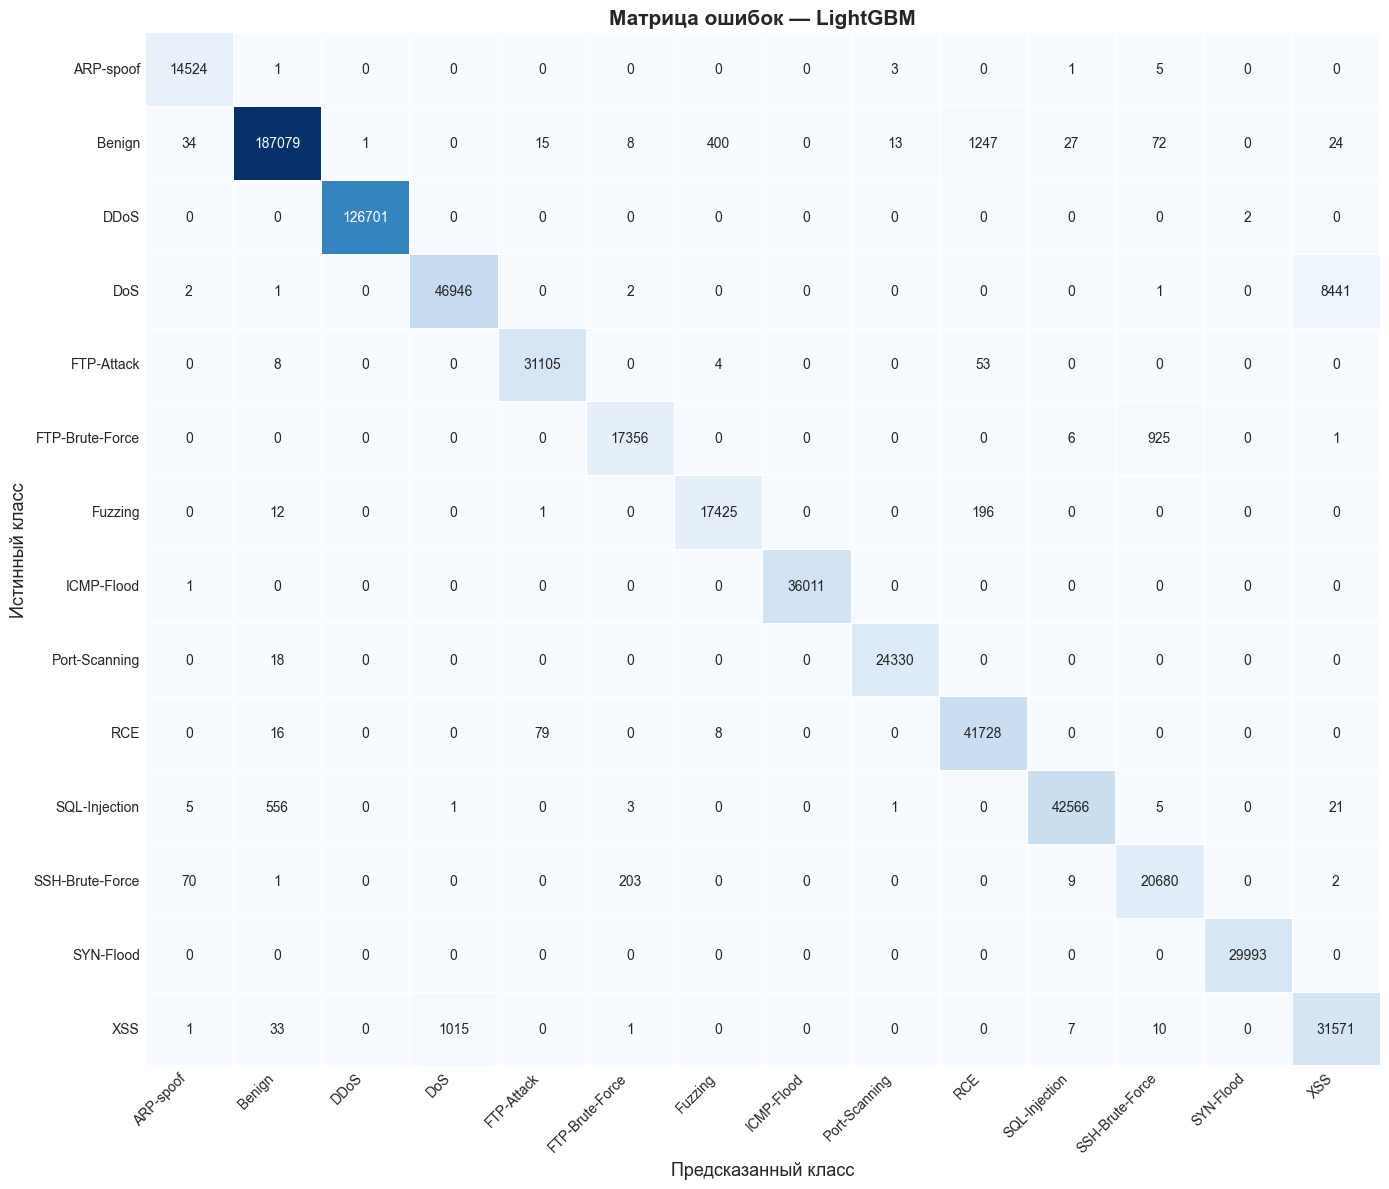


Classification Report (Val):
                 precision    recall  f1-score   support

      ARP-spoof     0.9923    0.9993    0.9958     14534
         Benign     0.9966    0.9903    0.9934    188920
           DDoS     1.0000    1.0000    1.0000    126703
            DoS     0.9788    0.8475    0.9084     55393
     FTP-Attack     0.9970    0.9979    0.9974     31170
FTP-Brute-Force     0.9877    0.9490    0.9680     18288
        Fuzzing     0.9769    0.9881    0.9825     17634
     ICMP-Flood     1.0000    1.0000    1.0000     36012
  Port-Scanning     0.9993    0.9993    0.9993     24348
            RCE     0.9654    0.9975    0.9812     41831
  SQL-Injection     0.9988    0.9863    0.9925     43158
SSH-Brute-Force     0.9531    0.9864    0.9695     20965
      SYN-Flood     0.9999    1.0000    1.0000     29993
            XSS     0.7881    0.9673    0.8686     32638

       accuracy                         0.9801    681587
      macro avg     0.9738    0.9792    0.9755    681587

In [16]:
cm = confusion_matrix(y_val_encoded, y_val_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.xlabel('Предсказанный класс', fontsize=13)
plt.ylabel('Истинный класс',      fontsize=13)
plt.title('Матрица ошибок — LightGBM', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report (Val):")
print(classification_report(y_val_encoded, y_val_pred, target_names=le.classes_, digits=4))

In [17]:
mask = (y_val_encoded != y_val_pred)

if mask.sum() > 0:
    err_df    = pd.DataFrame({'true': y_val_encoded[mask], 'pred': y_val_pred[mask]})
    top_errors = (err_df.groupby(['true', 'pred']).size()
                        .reset_index(name='count')
                        .sort_values('count', ascending=False)
                        .head(10))
    total = int(mask.sum())
    print(f"Всего ошибок: {total} ({total/len(y_val_encoded)*100:.2f}%)")
    print(f"Точность на валидации: {(~mask).sum()/len(y_val_encoded):.2%}")
    print("-" * 70)
    for _, row in top_errors.iterrows():
        t = le.classes_[int(row['true'])]
        p = le.classes_[int(row['pred'])]
        c = int(row['count'])
        print(f"   • {t:<20s} -> {p:<20s} : {c:>6} случаев ({c/total*100:.1f}%)")
    print("-" * 70)
else:
    print("Ошибок не обнаружено на валидационной выборке!")

test_err = int((y_test_encoded != y_test_pred).sum())
print(f"\nTest Accuracy: {test_acc:.4f}  |  Ошибок: {test_err} ({test_err/len(y_test_encoded)*100:.2f}%)")

Всего ошибок: 13572 (1.99%)
Точность на валидации: 98.01%
----------------------------------------------------------------------
   • DoS                  -> XSS                  :   8441 случаев (62.2%)
   • Benign               -> RCE                  :   1247 случаев (9.2%)
   • XSS                  -> DoS                  :   1015 случаев (7.5%)
   • FTP-Brute-Force      -> SSH-Brute-Force      :    925 случаев (6.8%)
   • SQL-Injection        -> Benign               :    556 случаев (4.1%)
   • Benign               -> Fuzzing              :    400 случаев (2.9%)
   • SSH-Brute-Force      -> FTP-Brute-Force      :    203 случаев (1.5%)
   • Fuzzing              -> RCE                  :    196 случаев (1.4%)
   • RCE                  -> FTP-Attack           :     79 случаев (0.6%)
   • Benign               -> SSH-Brute-Force      :     72 случаев (0.5%)
----------------------------------------------------------------------

Test Accuracy: 0.9803  |  Ошибок: 13420 (1.97%)


Топ-20 важнейших признаков:
                          feature  importance
                  TCP_Source_Port       23787
             TCP_Destination_Port       21584
                     TCP_Checksum       14304
                      IP_Checksum       13842
        TCP_Acknowledgment_Number        9645
              TCP_Sequence_Number        7118
                        IP_Length        3840
                           Source        3519
                           Length        3504
                  TCP_Window_Size        3042
                  UDP_Source_Port        2882
                      Destination        2690
                   IP_Destination        2399
                     UDP_Checksum        2308
             Ethernet_Destination        2236
                         Protocol        1659
                        IP_Source         981
Ethernet_Source_08_00_27_5d_ef_d9         902
                  HTTP_User_Agent         885
                        TCP_Flags         877


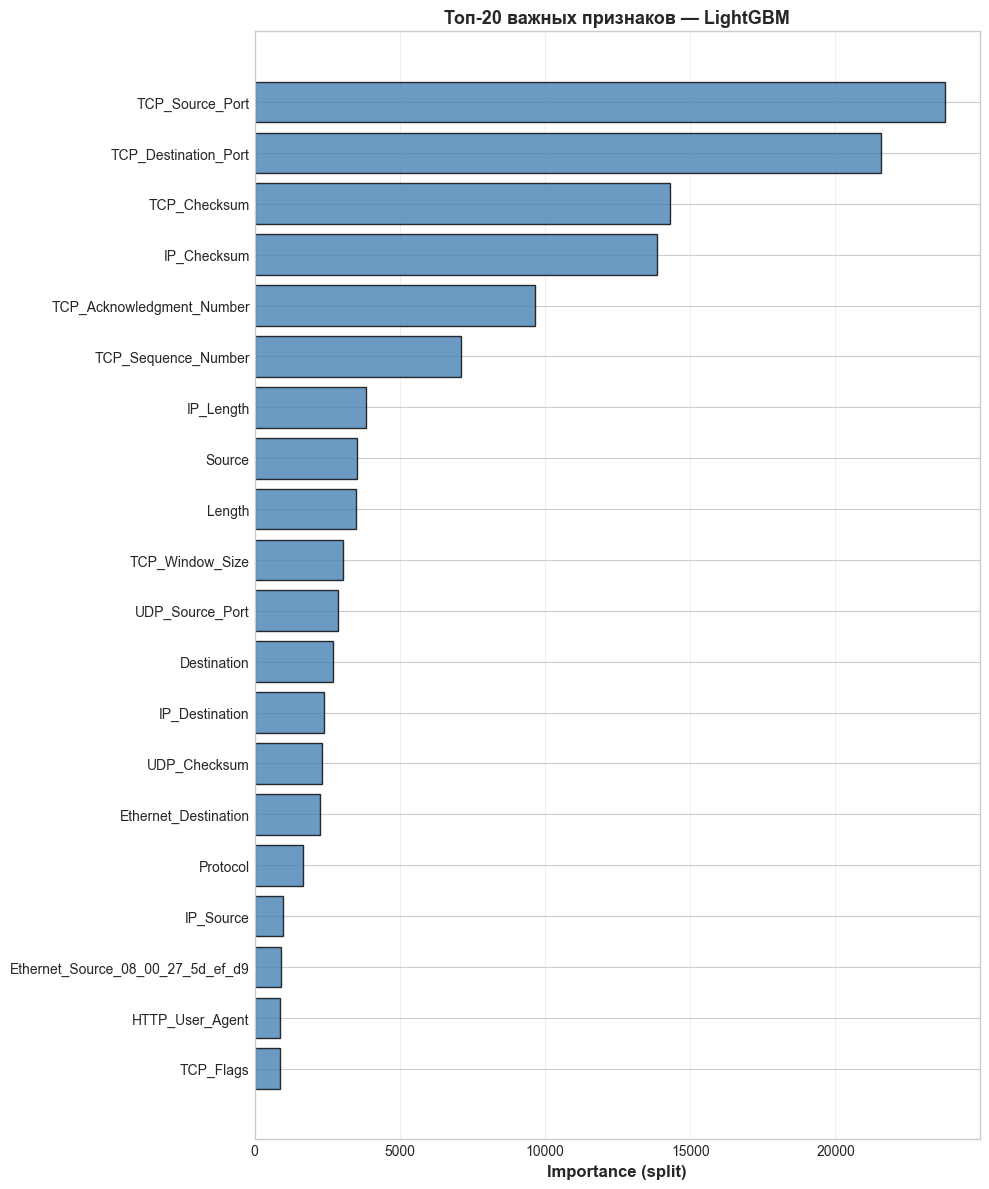

In [18]:
feature_names = list(X_train.columns)
feat_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Топ-20 важнейших признаков:")
print(feat_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 12))
top20 = feat_df.head(20)
ax.barh(range(len(top20)), top20['importance'], color='steelblue', edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'], fontsize=10)
ax.set_xlabel('Importance (split)', fontsize=12, fontweight='bold')
ax.set_title('Топ-20 важных признаков — LightGBM', fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/feature_importance_lgbm.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
model_path = os.path.join(MODEL_DIR, 'lgbm_optuna_best.joblib')
joblib.dump(final_model, model_path)
print(f"Модель сохранена: {model_path}")

enc_path = os.path.join(MODEL_DIR, 'label_encoder.joblib')
joblib.dump(le, enc_path)
print(f"LabelEncoder сохранён: {enc_path}")

joblib.dump(study, os.path.join(MODEL_DIR, 'optuna_study.joblib'))

with open(os.path.join(MODEL_DIR, 'feature_names.txt'), 'w') as f:
    f.write('\n'.join(feature_names))

meta = {
    "model_type":        "LightGBM",
    "metric_optimized":  "multi_logloss",
    "best_optuna_value": float(study.best_value),
    "best_params": {
        k: (float(v) if isinstance(v, float) else int(v) if isinstance(v, int) else v)
        for k, v in study.best_params.items()
    },
    "n_trials":        len(study.trials),
    "val_accuracy":    round(float(val_acc),   4),
    "test_accuracy":   round(float(test_acc),  4),
    "val_macro_f1":    round(float(macro_f1),  4),
    "val_macro_auc":   round(float(roc_macro), 4),
    "n_classes":       int(num_classes),
    "class_names":     le.classes_.tolist(),
    "features_count":  int(X_train.shape[1]),
    "best_iteration":  int(final_model.best_iteration_),
}
with open(os.path.join(MODEL_DIR, 'meta.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print(f"Метаданные сохранены: {os.path.join(MODEL_DIR, 'meta.json')}")

print(f"\n--- Итоговые метрики ---")
print(f"   Val  Accuracy : {val_acc:.4f}")
print(f"   Test Accuracy : {test_acc:.4f}")
print(f"   Val Macro F1  : {macro_f1:.4f}")
print(f"   Val Macro AUC : {roc_macro:.4f}")

Модель сохранена: processed/models/lgbm\lgbm_optuna_best.joblib
LabelEncoder сохранён: processed/models/lgbm\label_encoder.joblib
Метаданные сохранены: processed/models/lgbm\meta.json

--- Итоговые метрики ---
   Val  Accuracy : 0.9801
   Test Accuracy : 0.9803
   Val Macro F1  : 0.9755
   Val Macro AUC : 0.9997
